# Amazon-Style E-Commerce Sales Analytics

## 02 — Exploratory Data Analysis

### Objective

The objective of this notebook is to explore the cleaned Amazon-style e-commerce dataset and identify meaningful patterns in sales, orders, products, customers, payment methods, order status, discounts, and geographic performance.

### Analytical Goals

- Understand overall business performance
- Analyze revenue and order trends
- Identify high-performing categories, brands, and products
- Understand customer purchasing behavior
- Analyze order status and payment methods
- Examine discount patterns
- Explore geographic distribution
- Identify relationships between important numerical variables
- Generate initial business insights for further analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
file_path = "C:/Users/Hp/OneDrive/Desktop/Projects/Amazon E-Commerce Sales Performance & Customer Analytics/Data/Amazon_Cleaned.csv"

df = pd.read_csv(file_path)

print("Cleaned dataset loaded successfully.")

Cleaned dataset loaded successfully.


In [3]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

print(df["OrderDate"].dtype)

datetime64[us]


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nDate Range:")
print("Start:", df["OrderDate"].min())
print("End:", df["OrderDate"].max())

print("\nUnique Business Entities:")
print("Orders:", df["OrderID"].nunique())
print("Customers:", df["CustomerID"].nunique())
print("Products:", df["ProductID"].nunique())
print("Sellers:", df["SellerID"].nunique())
print("Categories:", df["Category"].nunique())
print("Brands:", df["Brand"].nunique())

Rows: 100000
Columns: 25

Date Range:
Start: 2020-01-01 00:00:00
End: 2024-12-29 00:00:00

Unique Business Entities:
Orders: 100000
Customers: 43233
Products: 50
Sellers: 1999
Categories: 6
Brands: 10


In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
OrderDate,100000,2022-06-30 23:55:49.439999,2020-01-01 00:00:00,2021-04-01 00:00:00,2022-07-01 00:00:00,2023-09-29 00:00:00,2024-12-29 00:00:00,NaN
Quantity,100000.0,3.0014,1.0,2.0,3.0,4.0,5.0,1.413548
UnitPrice,100000.0,302.905748,5.0,154.19,303.07,451.5,599.99,171.840797
Discount,100000.0,0.074226,0.0,0.0,0.05,0.1,0.3,0.082583
Tax,100000.0,68.468902,0.0,15.92,45.25,96.06,538.46,74.13118
ShippingCost,100000.0,7.40666,0.0,3.68,7.3,11.15,15.0,4.324057
TotalAmount,100000.0,918.256479,4.27,340.89,714.315,1349.765,3534.98,724.508332
Year,100000.0,2021.99814,2020.0,2021.0,2022.0,2023.0,2024.0,1.413264
Month,100000.0,6.51054,1.0,4.0,7.0,9.0,12.0,3.444408
Quarter,100000.0,2.50375,1.0,2.0,3.0,3.0,4.0,1.113893


In [6]:
df[
    [
        "Quantity",
        "UnitPrice",
        "Discount",
        "Tax",
        "ShippingCost",
        "TotalAmount"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,100000.0,3.001400,1.413548,1.00,2.00,3.000,4.000,5.00
UnitPrice,100000.0,302.905748,171.840797,5.00,154.19,303.070,451.500,599.99
Discount,100000.0,0.074226,0.082583,0.00,0.00,0.050,0.100,0.30
Tax,100000.0,68.468902,74.131180,0.00,15.92,45.250,96.060,538.46
ShippingCost,100000.0,7.406660,4.324057,0.00,3.68,7.300,11.150,15.00
TotalAmount,100000.0,918.256479,724.508332,4.27,340.89,714.315,1349.765,3534.98


In [9]:
total_revenue = df["TotalAmount"].sum()
total_orders = df["OrderID"].nunique()
total_units = df["Quantity"].sum()
total_customers = df["CustomerID"].nunique()
total_products = df["ProductID"].nunique()
average_order_value = total_revenue / total_orders

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Units Sold",
        "Customers",
        "Products",
        "Average Order Value"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_units,
        total_customers,
        total_products,
        average_order_value
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,9.182565e+07
1,Total Orders,1.000000e+05
2,Units Sold,3.001400e+05
3,Customers,4.323300e+04
4,Products,5.000000e+01
5,Average Order Value,9.182565e+02


In [11]:
print(f"Total Revenue      : ${total_revenue:,.2f}")
print(f"Total Orders       : {total_orders:,}")
print(f"Units Sold         : {total_units:,}")
print(f"Customers          : {total_customers:,}")
print(f"Products           : {total_products:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")

Total Revenue      : $91,825,647.92
Total Orders       : 100,000
Units Sold         : 300,140
Customers          : 43,233
Products           : 50
Average Order Value: $918.26


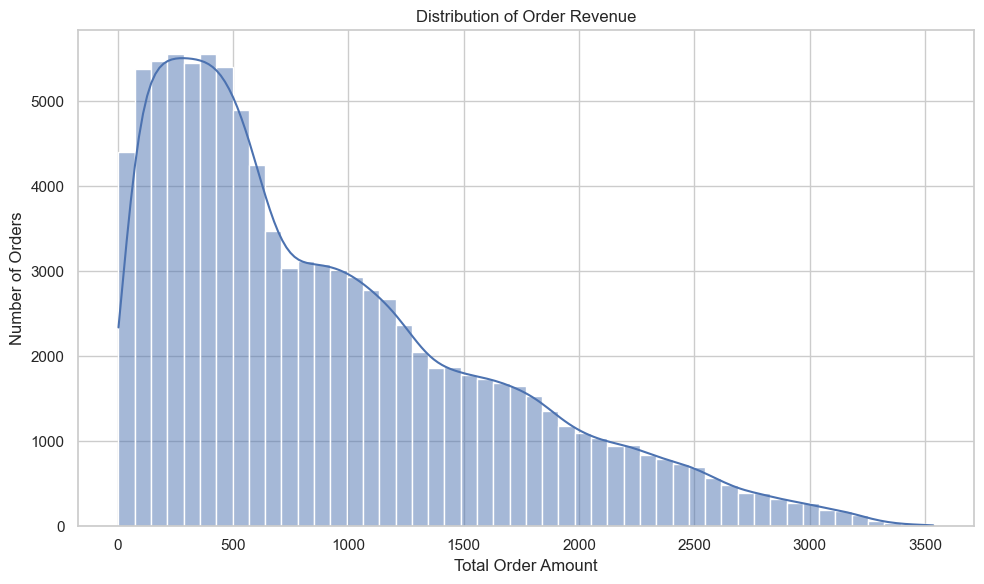

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["TotalAmount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Order Revenue")
plt.xlabel("Total Order Amount")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

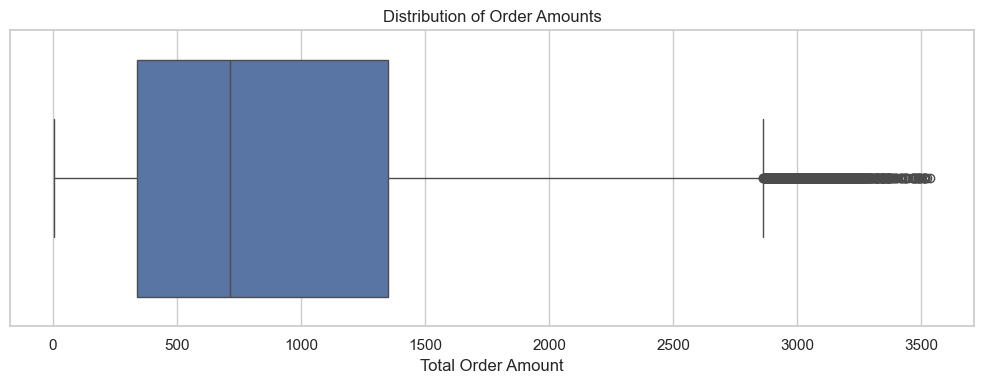

In [13]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["TotalAmount"]
)

plt.title("Distribution of Order Amounts")
plt.xlabel("Total Order Amount")

plt.tight_layout()
plt.show()

In [14]:
df["TotalAmount"].describe()

count    100000.000000
mean        918.256479
std         724.508332
min           4.270000
25%         340.890000
50%         714.315000
75%        1349.765000
max        3534.980000
Name: TotalAmount, dtype: float64

In [15]:
yearly_sales = (
    df.groupby("Year")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum")
      )
      .reset_index()
)

yearly_sales

,Year,Revenue,Orders,Units
0,2020,18529864.02,20066,60208
1,2021,18248574.81,19890,59641
2,2022,18367248.41,20078,60126
3,2023,18513912.19,20096,60577
4,2024,18166048.49,19870,59588


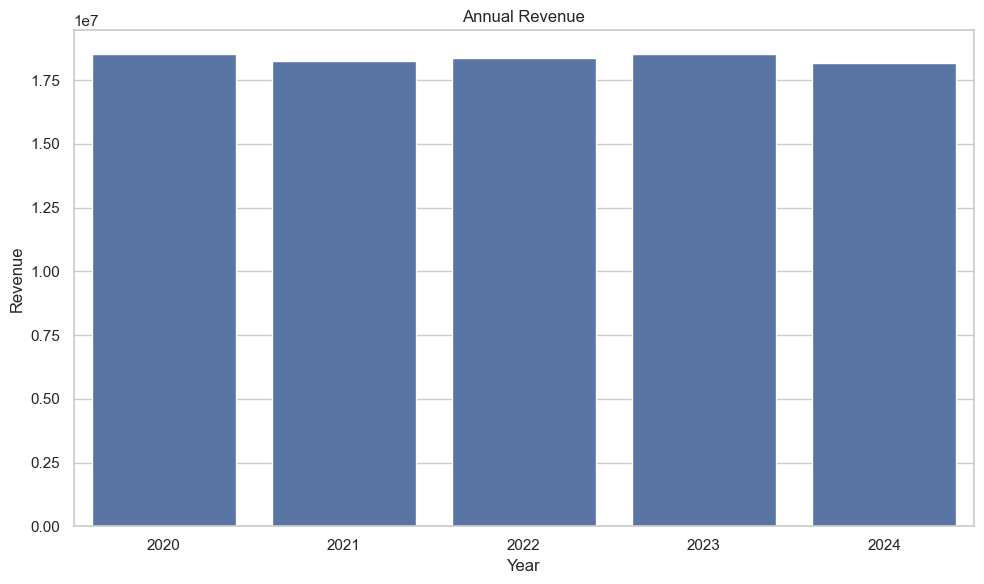

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Revenue"
)

plt.title("Annual Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [17]:
yearly_sales["Revenue_Growth_%"] = (
    yearly_sales["Revenue"]
    .pct_change() * 100
)

yearly_sales

,Year,Revenue,Orders,Units,Revenue_Growth_%
0,2020,18529864.02,20066,60208,NaN
1,2021,18248574.81,19890,59641,-1.518032
2,2022,18367248.41,20078,60126,0.650317
3,2023,18513912.19,20096,60577,0.798507
4,2024,18166048.49,19870,59588,-1.878931


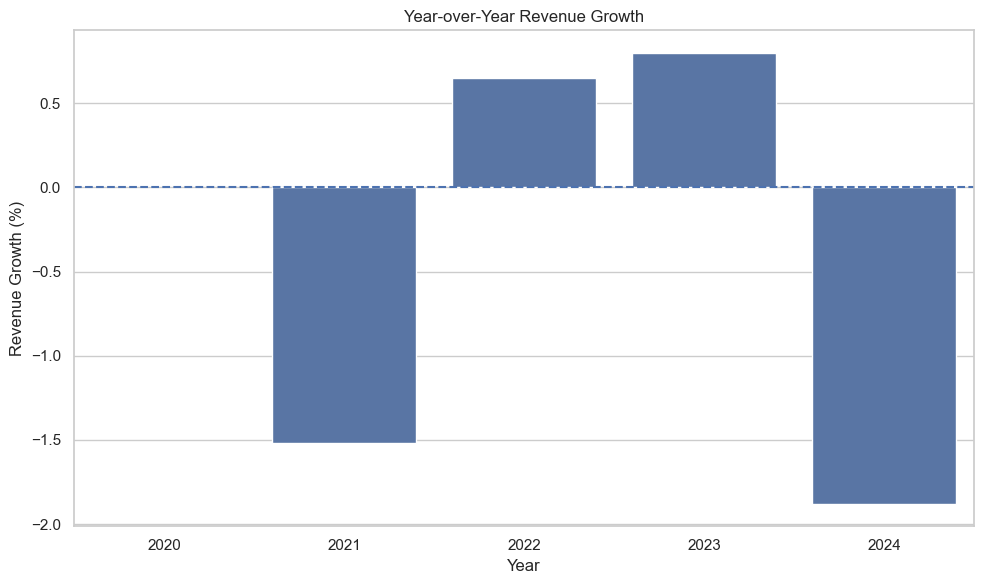

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Revenue_Growth_%"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Year-over-Year Revenue Growth")
plt.xlabel("Year")
plt.ylabel("Revenue Growth (%)")

plt.tight_layout()
plt.show()

In [19]:
monthly_sales = (
    df.groupby("YearMonth")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum")
      )
      .reset_index()
)

monthly_sales.head()

,YearMonth,Revenue,Orders,Units
0,2020-01,1637069.40,1730,5225
1,2020-02,1339388.21,1490,4343
2,2020-03,1587125.66,1685,5050
3,2020-04,1588347.29,1692,5156
4,2020-05,1533834.17,1672,5061


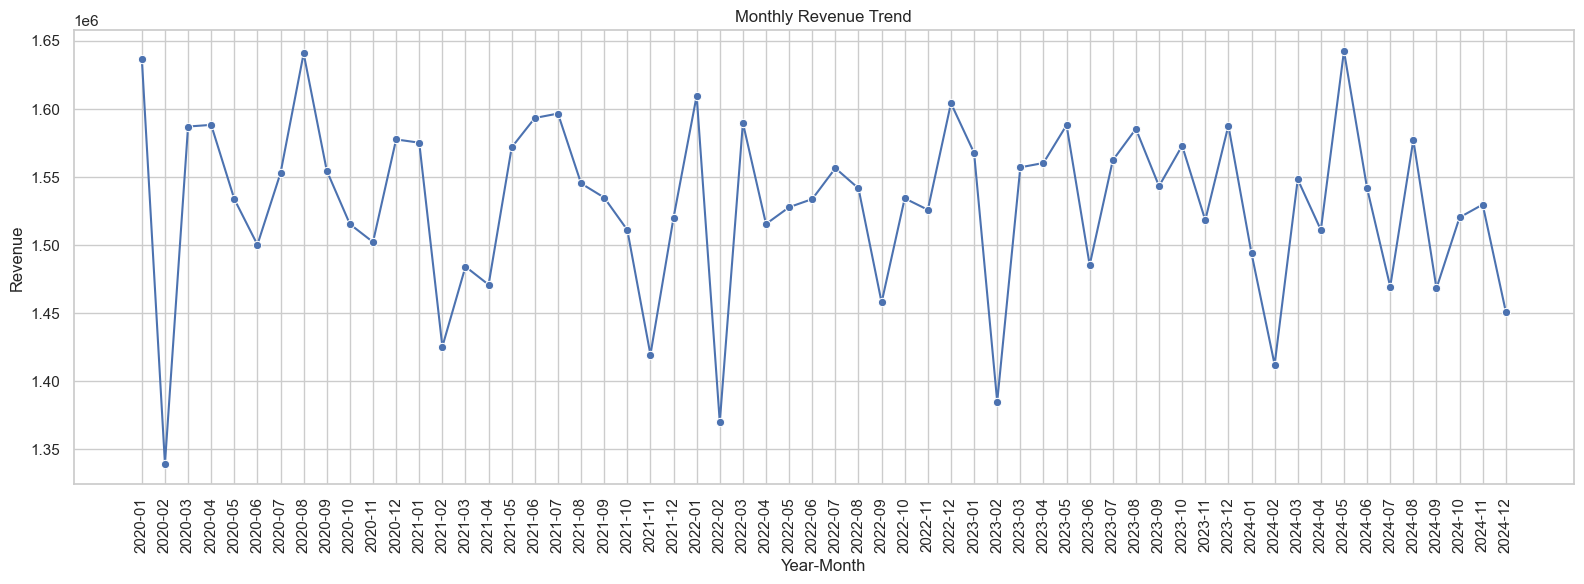

In [20]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=monthly_sales,
    x="YearMonth",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [21]:
monthly_sales.sort_values(
    "Revenue",
    ascending=False
).head(10)

,YearMonth,Revenue,Orders,Units
52,2024-05,1642609.94,1753,5306
7,2020-08,1640874.93,1783,5439
0,2020-01,1637069.40,1730,5225
24,2022-01,1609759.87,1744,5270
35,2022-12,1604276.23,1753,5241
18,2021-07,1596668.40,1718,5142
17,2021-06,1593398.08,1668,5129
26,2022-03,1589809.35,1710,5089
3,2020-04,1588347.29,1692,5156
40,2023-05,1588151.65,1709,5100


In [24]:
monthly_sales.sort_values(
    "Revenue",
    ascending=True
).head(10)

,YearMonth,Revenue,Orders,Units
1,2020-02,1339388.21,1490,4343
25,2022-02,1369866.29,1510,4525
37,2023-02,1384957.09,1540,4586
49,2024-02,1412146.91,1562,4692
22,2021-11,1419480.77,1587,4674
13,2021-02,1425365.99,1516,4524
59,2024-12,1451073.77,1577,4721
32,2022-09,1457859.60,1645,4850
56,2024-09,1468209.92,1613,4735
54,2024-07,1469460.10,1631,4833


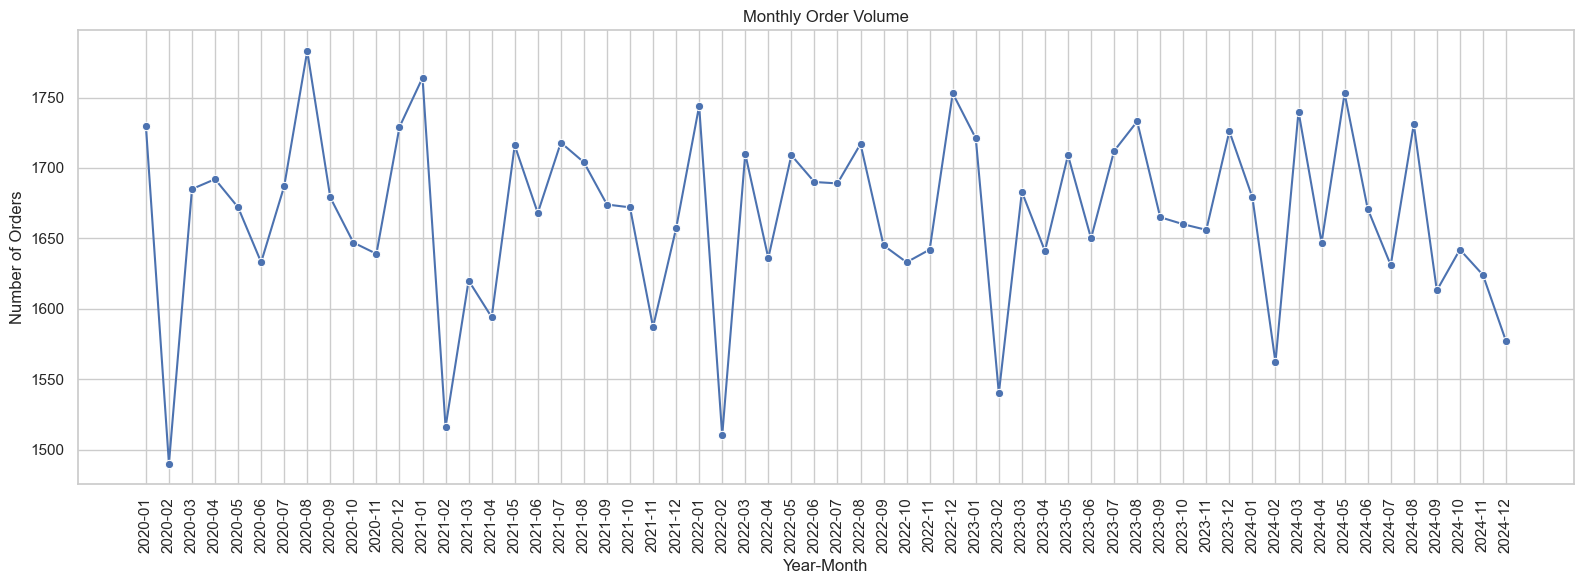

In [25]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=monthly_sales,
    x="YearMonth",
    y="Orders",
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Year-Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [26]:
category_sales = (
    df.groupby("Category")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum"),
          Average_Order_Value=("TotalAmount", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

category_sales

,Revenue,Orders,Units,Average_Order_Value
Category,,,,
Electronics,15584217.18,16853,50696,924.714720
Sports & Outdoors,15345571.88,16804,50543,913.209467
Books,15261837.01,16752,49981,911.045667
Clothing,15253397.50,16439,49523,927.878673
Toys & Games,15216684.99,16542,49773,919.881815
Home & Kitchen,15163939.36,16610,49624,912.940359


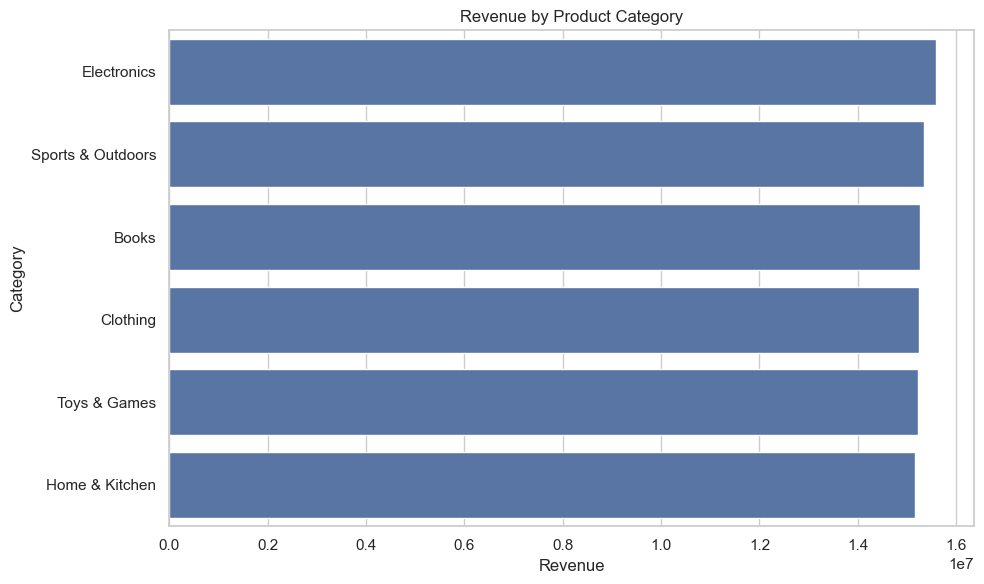

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_sales.reset_index(),
    x="Revenue",
    y="Category"
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

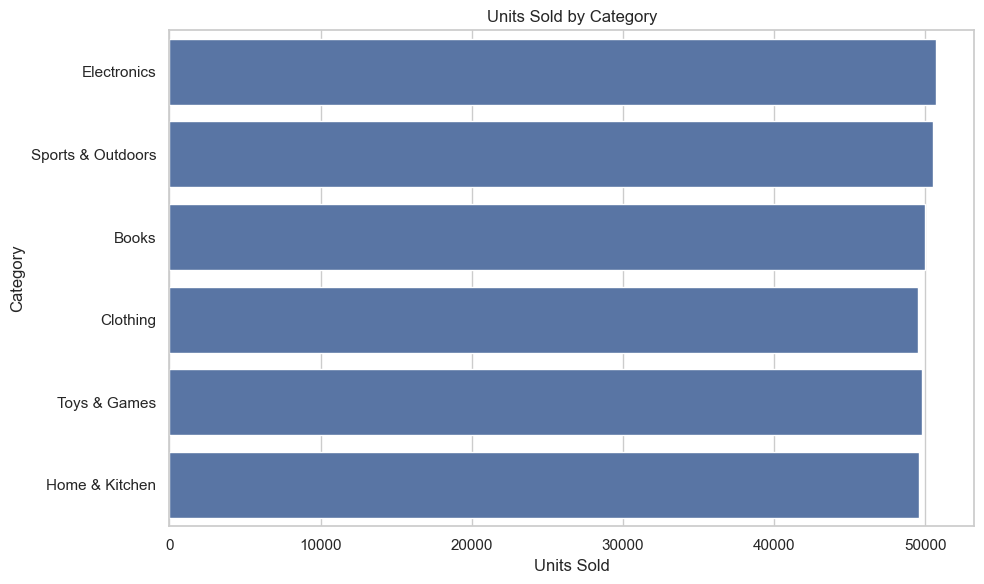

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_sales.reset_index(),
    x="Units",
    y="Category"
)

plt.title("Units Sold by Category")
plt.xlabel("Units Sold")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [29]:
category_sales["Revenue_Share_%"] = (
    category_sales["Revenue"] /
    category_sales["Revenue"].sum() * 100
)

category_sales

,Revenue,Orders,Units,Average_Order_Value,Revenue_Share_%
Category,,,,,
Electronics,15584217.18,16853,50696,924.714720,16.971530
Sports & Outdoors,15345571.88,16804,50543,913.209467,16.711640
Books,15261837.01,16752,49981,911.045667,16.620451
Clothing,15253397.50,16439,49523,927.878673,16.611260
Toys & Games,15216684.99,16542,49773,919.881815,16.571280
Home & Kitchen,15163939.36,16610,49624,912.940359,16.513839


In [30]:
brand_sales = (
    df.groupby("Brand")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

brand_sales

,Revenue,Orders,Units
Brand,,,
CoreTech,9343720.59,10127,30430
KiddoFun,9324749.55,10077,30168
ReadMore,9278406.63,10204,30421
UrbanStyle,9249027.45,9854,30104
Zenith,9239960.39,9990,30058
Apex,9147604.72,9937,29955
NexPro,9078824.97,9962,29791
FitLife,9061444.68,10147,30121
BrightLux,9056816.11,9907,29616


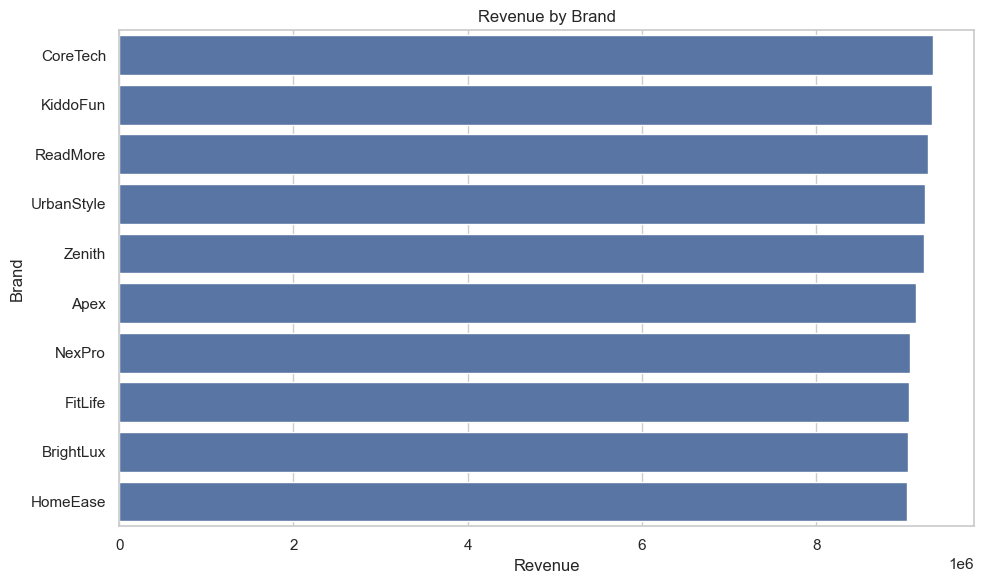

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=brand_sales.reset_index(),
    x="Revenue",
    y="Brand"
)

plt.title("Revenue by Brand")
plt.xlabel("Revenue")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

In [32]:
product_sales = (
    df.groupby(["ProductID", "ProductName"])
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

top_10_products = product_sales.head(10)

top_10_products

,,Revenue,Orders,Units
ProductID,ProductName,,,
P00047,Memory Card 128GB,1935138.40,2039,6240
P00019,LED Desk Lamp,1921948.41,2098,6344
P00007,Mechanical Keyboard,1906963.54,2034,6161
P00017,Electric Kettle,1905751.79,2054,6165
P00010,Smartwatch,1901275.59,1989,5983
P00030,Dress Shirt,1896765.36,2007,5960
P00022,Water Bottle,1895467.95,2088,6275
P00006,Gaming Mouse,1895103.98,2010,6170
P00031,Kids Toy Car,1891082.43,2004,6131


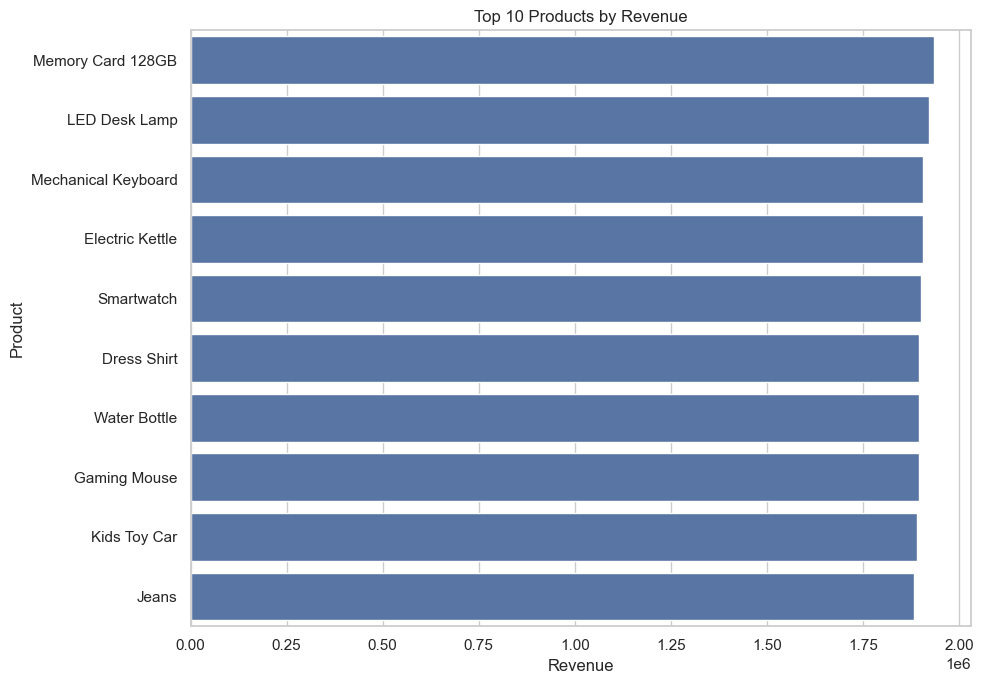

In [33]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_10_products.reset_index(),
    x="Revenue",
    y="ProductName"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [36]:
top_products_units = (
    product_sales
    .sort_values("Units", ascending=False)
    .head(10)
)

top_products_units

,,Revenue,Orders,Units
ProductID,ProductName,,,
P00019,LED Desk Lamp,1921948.41,2098,6344
P00022,Water Bottle,1895467.95,2088,6275
P00047,Memory Card 128GB,1935138.40,2039,6240
P00037,Router,1850756.20,2054,6202
P00032,Board Game,1863310.96,2039,6200
P00040,Microphone,1871740.68,2034,6196
P00006,Gaming Mouse,1895103.98,2010,6170
P00017,Electric Kettle,1905751.79,2054,6165
P00007,Mechanical Keyboard,1906963.54,2034,6161


In [37]:
status_summary = (
    df["OrderStatus"]
    .value_counts()
    .reset_index()
)

status_summary.columns = [
    "OrderStatus",
    "Orders"
]

status_summary["Percentage"] = (
    status_summary["Orders"] /
    status_summary["Orders"].sum() * 100
)

status_summary

,OrderStatus,Orders,Percentage
0,Delivered,74628,74.628
1,Shipped,15192,15.192
2,Pending,4103,4.103
3,Returned,3049,3.049
4,Cancelled,3028,3.028


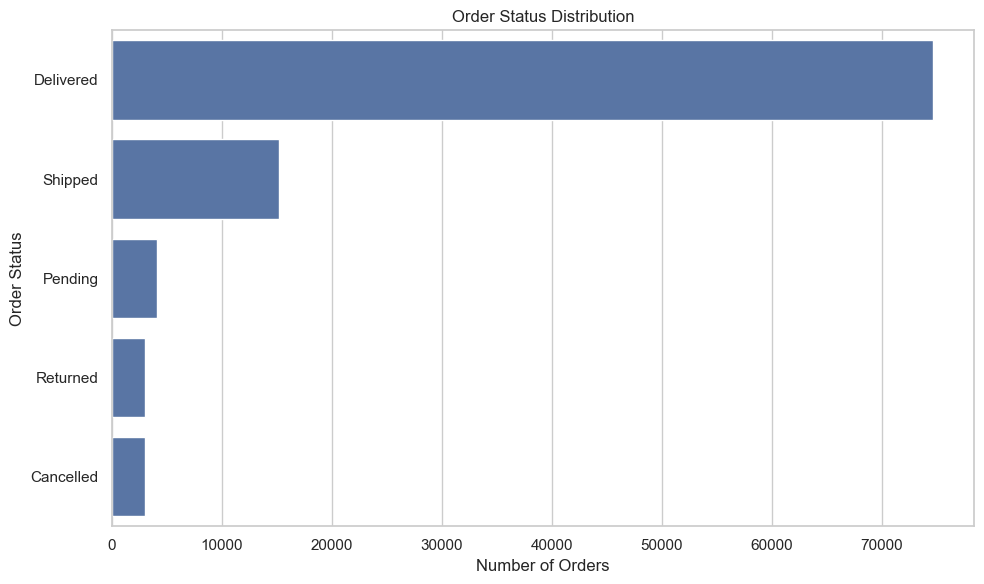

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=status_summary,
    x="Orders",
    y="OrderStatus"
)

plt.title("Order Status Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Order Status")

plt.tight_layout()
plt.show()

In [39]:
return_rate = (
    (df["OrderStatus"] == "Returned").mean() * 100
)

cancel_rate = (
    (df["OrderStatus"] == "Cancelled").mean() * 100
)

print(f"Return Rate     : {return_rate:.2f}%")
print(f"Cancellation Rate: {cancel_rate:.2f}%")

Return Rate     : 3.05%
Cancellation Rate: 3.03%


In [40]:
payment_summary = (
    df.groupby("PaymentMethod")
      .agg(
          Orders=("OrderID", "nunique"),
          Revenue=("TotalAmount", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

payment_summary

,Orders,Revenue
PaymentMethod,,
Credit Card,35038,32122158.69
Debit Card,20024,18538678.53
UPI,15066,13896028.55
Amazon Pay,15017,13697498.42
Net Banking,9927,9055674.57
Cash on Delivery,4928,4515609.16


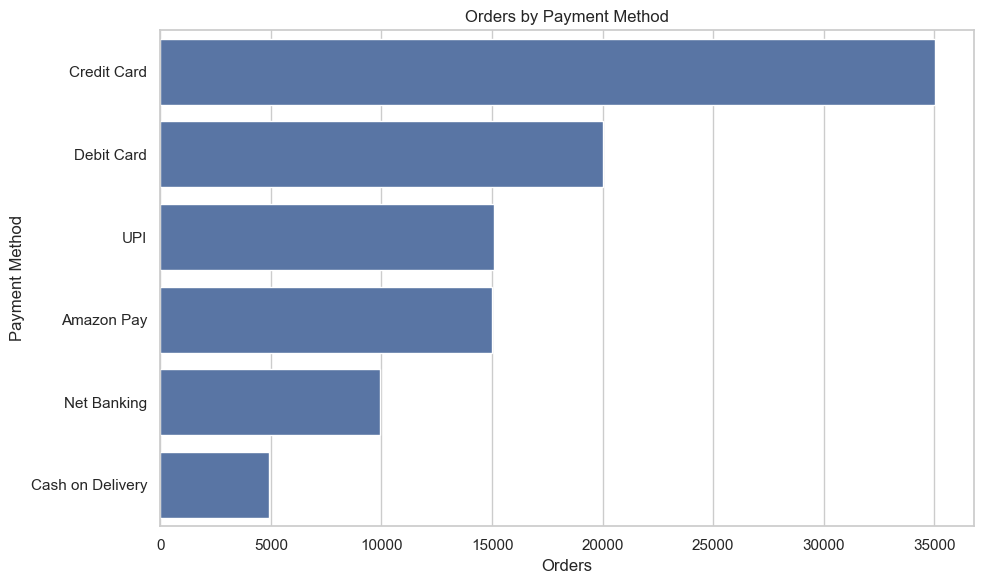

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_summary.reset_index(),
    x="Orders",
    y="PaymentMethod"
)

plt.title("Orders by Payment Method")
plt.xlabel("Orders")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

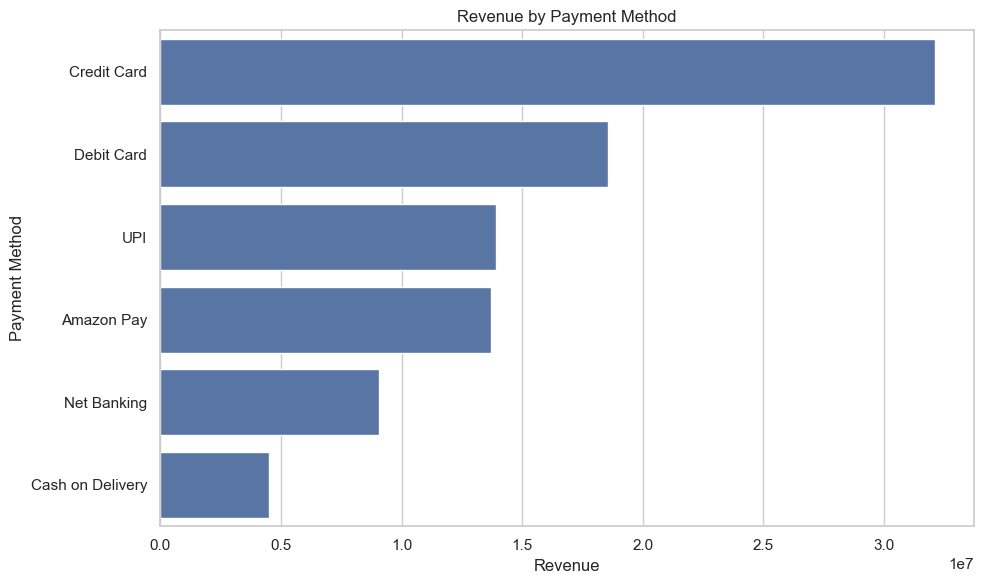

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_summary.reset_index(),
    x="Revenue",
    y="PaymentMethod"
)

plt.title("Revenue by Payment Method")
plt.xlabel("Revenue")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

In [43]:
customer_summary = (
    df.groupby("CustomerID")
      .agg(
          Orders=("OrderID", "nunique"),
          Revenue=("TotalAmount", "sum"),
          Units=("Quantity", "sum")
      )
)

customer_summary.describe()

,Orders,Revenue,Units
count,43233.000000,43233.000000,43233.000000
mean,2.313048,2123.971224,6.942382
std,1.257115,1594.379364,4.347894
min,1.000000,6.190000,1.000000
25%,1.000000,876.190000,4.000000
50%,2.000000,1805.410000,6.000000
75%,3.000000,2992.430000,9.000000
max,10.000000,15215.790000,35.000000


In [44]:
repeat_customers = (
    customer_summary["Orders"] > 1
).sum()

one_time_customers = (
    customer_summary["Orders"] == 1
).sum()

total_customers = len(customer_summary)

repeat_customer_rate = (
    repeat_customers / total_customers * 100
)

print(f"Total Customers      : {total_customers:,}")
print(f"One-Time Customers   : {one_time_customers:,}")
print(f"Repeat Customers     : {repeat_customers:,}")
print(f"Repeat Customer Rate : {repeat_customer_rate:.2f}%")

Total Customers      : 43,233
One-Time Customers   : 13,532
Repeat Customers     : 29,701
Repeat Customer Rate : 68.70%


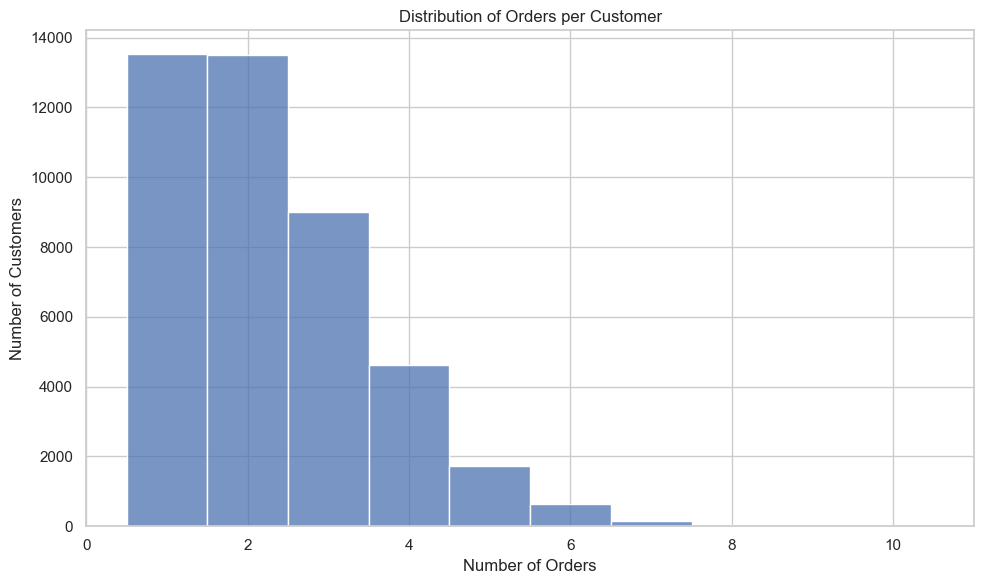

In [45]:
plt.figure(figsize=(10, 6))

sns.histplot(
    customer_summary["Orders"],
    discrete=True
)

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [46]:
top_customers = (
    customer_summary
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_customers

,Orders,Revenue,Units
CustomerID,,,
CUST023748,10,15215.79,33
CUST009614,9,12160.96,29
CUST034178,6,11418.88,23
CUST001153,9,11282.96,27
CUST004883,5,11214.44,22
CUST000787,7,10962.32,28
CUST015677,5,10956.10,22
CUST042689,8,10726.80,28
CUST015231,6,10638.79,27


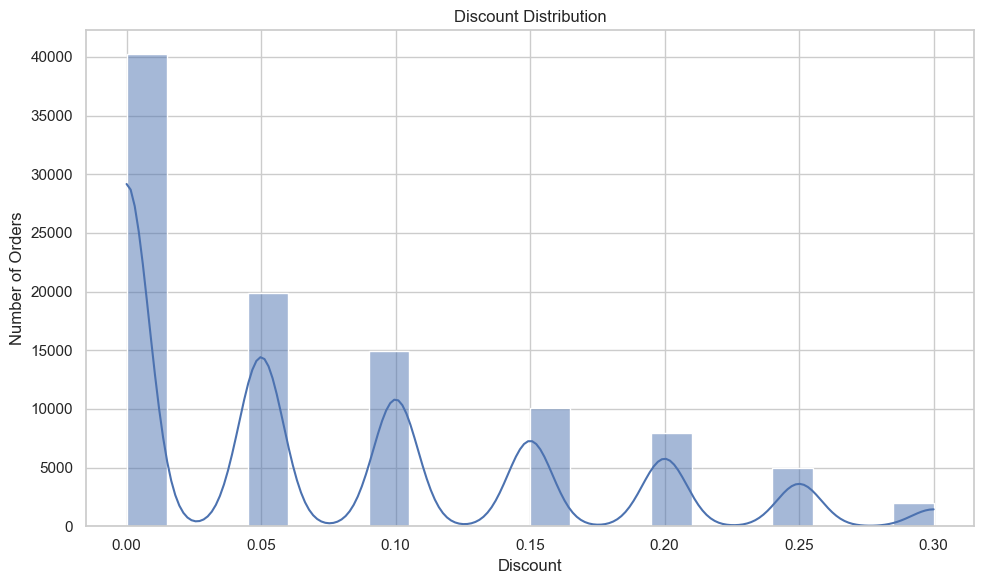

In [47]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Discount"],
    bins=20,
    kde=True
)

plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [48]:
discount_quantity = (
    df.groupby("Discount")
      .agg(
          Average_Quantity=("Quantity", "mean"),
          Orders=("OrderID", "count"),
          Revenue=("TotalAmount", "sum")
      )
      .reset_index()
)

discount_quantity

,Discount,Average_Quantity,Orders,Revenue
0,0.00,3.005938,40246,39759304.30
1,0.05,2.995123,19889,18754249.73
2,0.10,2.998726,14910,13391000.91
3,0.15,2.999104,10041,8451571.63
4,0.20,2.993576,7939,6301022.17
5,0.25,2.996189,4986,3723201.49
6,0.30,3.048265,1989,1445297.69


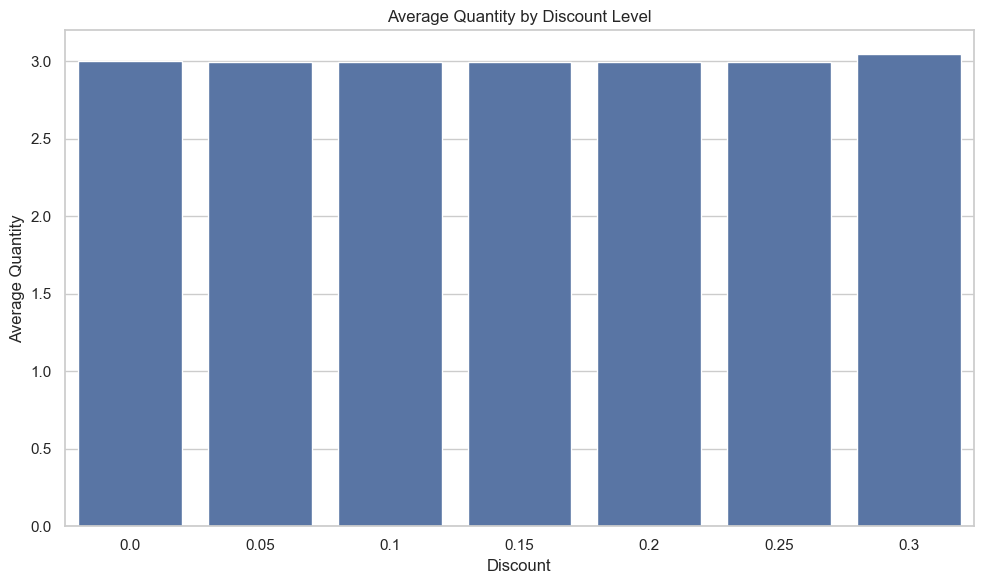

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_quantity,
    x="Discount",
    y="Average_Quantity"
)

plt.title("Average Quantity by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Quantity")

plt.tight_layout()
plt.show()

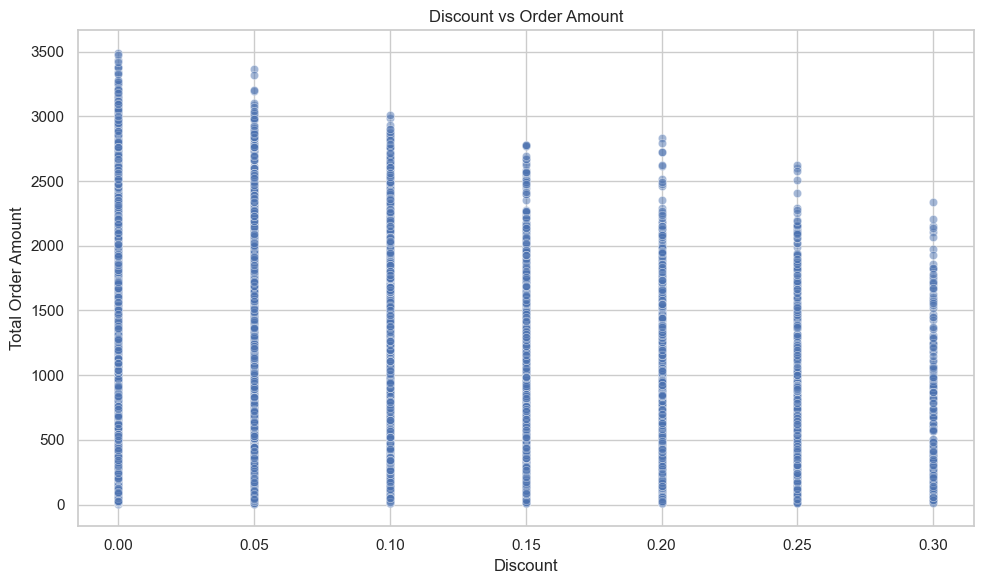

In [50]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(
        min(10000, len(df)),
        random_state=42
    ),
    x="Discount",
    y="TotalAmount",
    alpha=0.5
)

plt.title("Discount vs Order Amount")
plt.xlabel("Discount")
plt.ylabel("Total Order Amount")

plt.tight_layout()
plt.show()

In [51]:
country_sales = (
    df.groupby("Country")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

country_sales

,Revenue,Orders,Units
Country,,,
United States,64310048.50,70058,210409
India,13875839.12,15051,45082
Canada,5323757.00,5818,17381
United Kingdom,4526896.86,4943,14831
Australia,3789106.44,4130,12437


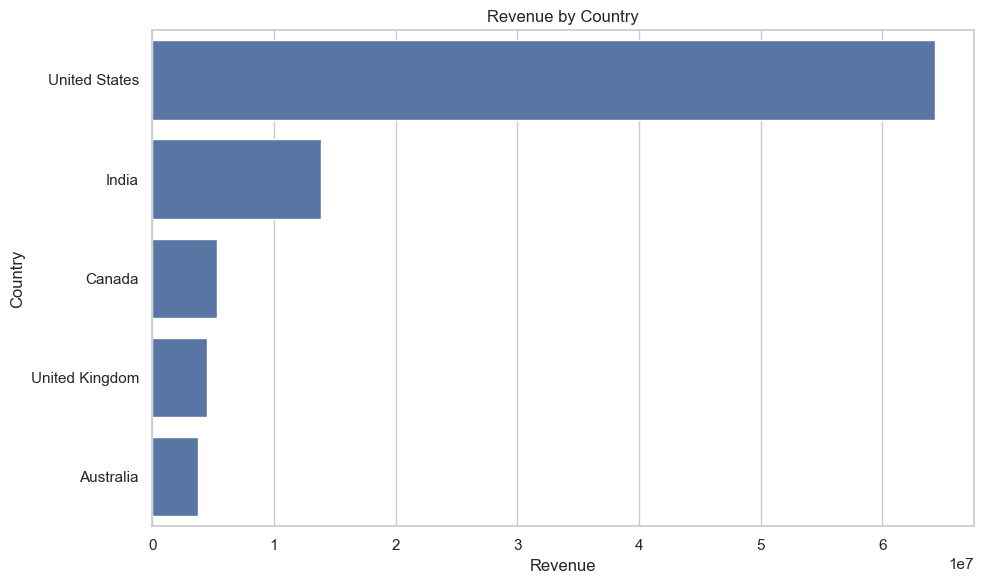

In [52]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=country_sales.reset_index(),
    x="Revenue",
    y="Country"
)

plt.title("Revenue by Country")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [53]:
country_sales["Revenue_Share_%"] = (
    country_sales["Revenue"] /
    country_sales["Revenue"].sum() * 100
)

country_sales

,Revenue,Orders,Units,Revenue_Share_%
Country,,,,
United States,64310048.50,70058,210409,70.034952
India,13875839.12,15051,45082,15.111071
Canada,5323757.00,5818,17381,5.797680
United Kingdom,4526896.86,4943,14831,4.929883
Australia,3789106.44,4130,12437,4.126414


In [54]:
correlation_columns = [
    "Quantity",
    "UnitPrice",
    "Discount",
    "Tax",
    "ShippingCost",
    "TotalAmount"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
Quantity,1.000000,0.004408,-0.000398,0.437884,0.020047,0.594928
UnitPrice,0.004408,1.000000,0.006159,0.526856,0.045773,0.715808
Discount,-0.000398,0.006159,1.000000,-0.077550,0.000315,-0.108088
Tax,0.437884,0.526856,-0.077550,1.000000,0.023498,0.779399
ShippingCost,0.020047,0.045773,0.000315,0.023498,1.000000,0.039349
TotalAmount,0.594928,0.715808,-0.108088,0.779399,0.039349,1.000000


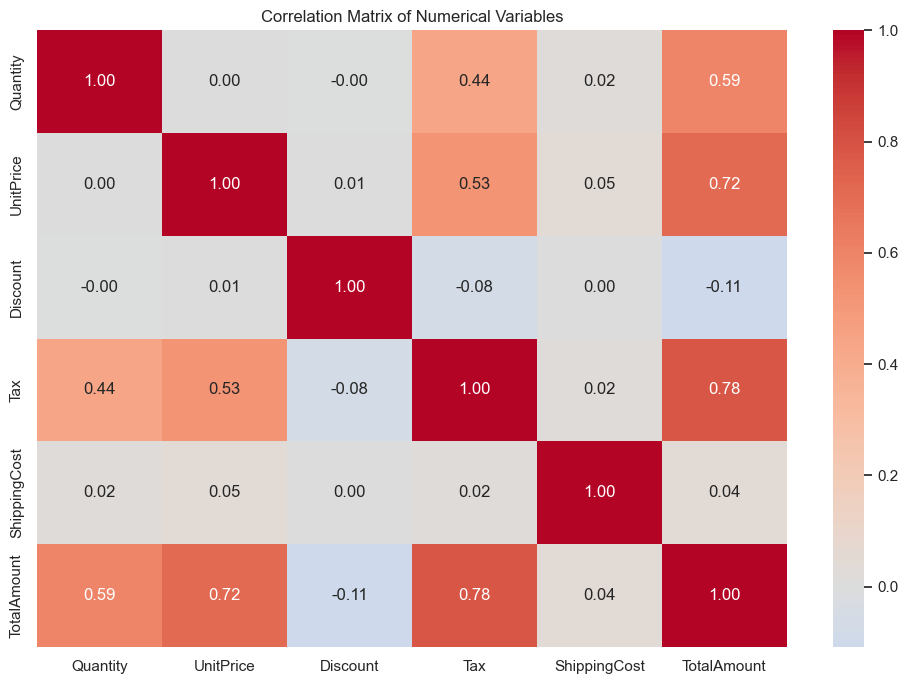

In [55]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

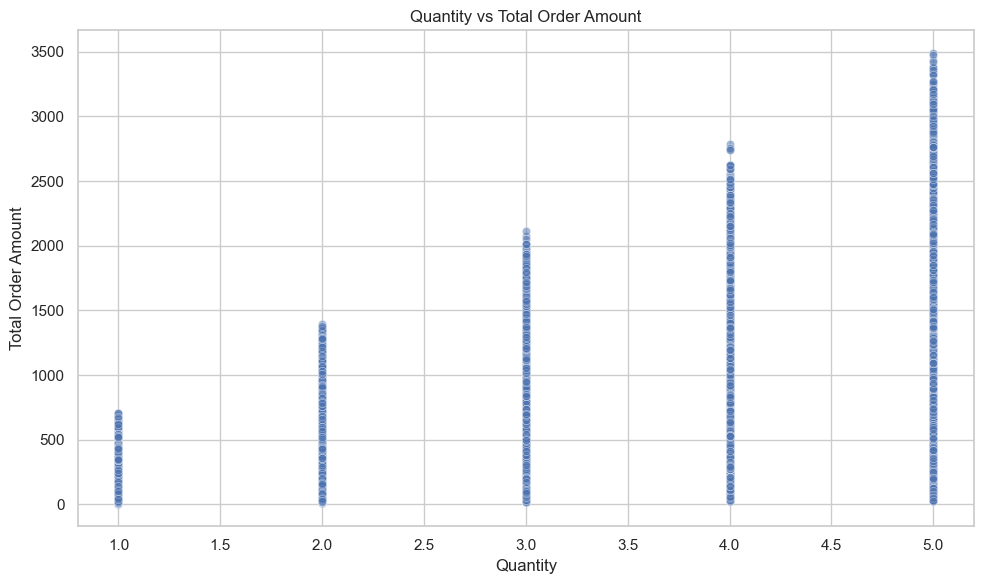

In [56]:
sample_df = df.sample(
    min(10000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Quantity",
    y="TotalAmount",
    alpha=0.5
)

plt.title("Quantity vs Total Order Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Order Amount")

plt.tight_layout()
plt.show()

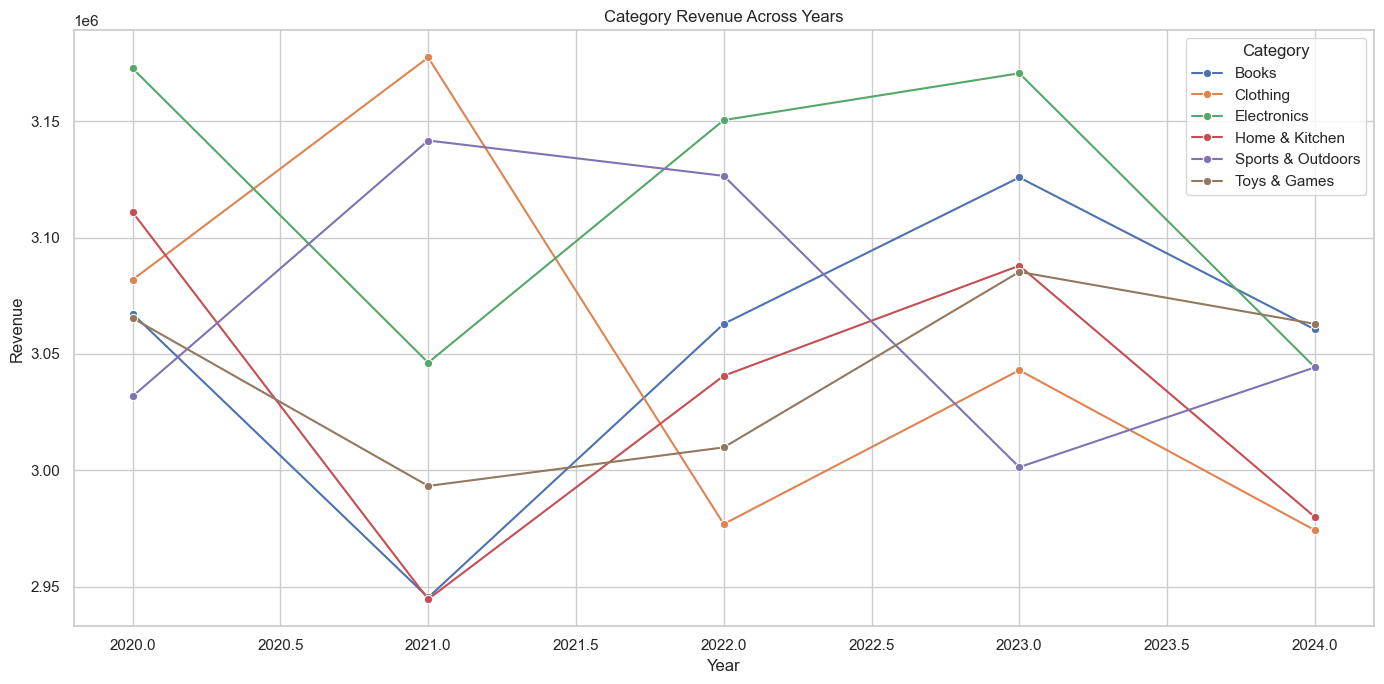

In [57]:
category_year = (
    df.groupby(["Year", "Category"])["TotalAmount"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=category_year,
    x="Year",
    y="TotalAmount",
    hue="Category",
    marker="o"
)

plt.title("Category Revenue Across Years")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [58]:
monthly_seasonality = (
    df.groupby(["Year", "Month"])["TotalAmount"]
      .sum()
      .reset_index()
      .groupby("Month")["TotalAmount"]
      .mean()
      .reset_index()
)

monthly_seasonality["MonthName"] = (
    pd.to_datetime(
        monthly_seasonality["Month"],
        format="%m"
    ).dt.month_name()
)

monthly_seasonality

,Month,TotalAmount,MonthName
0,1,1576760.254,January
1,2,1386344.898,February
2,3,1553305.546,March
3,4,1529240.644,April
4,5,1572856.654,May
5,6,1530927.350,June
6,7,1547585.102,July
7,8,1578119.674,August
8,9,1511794.170,September
9,10,1530848.664,October


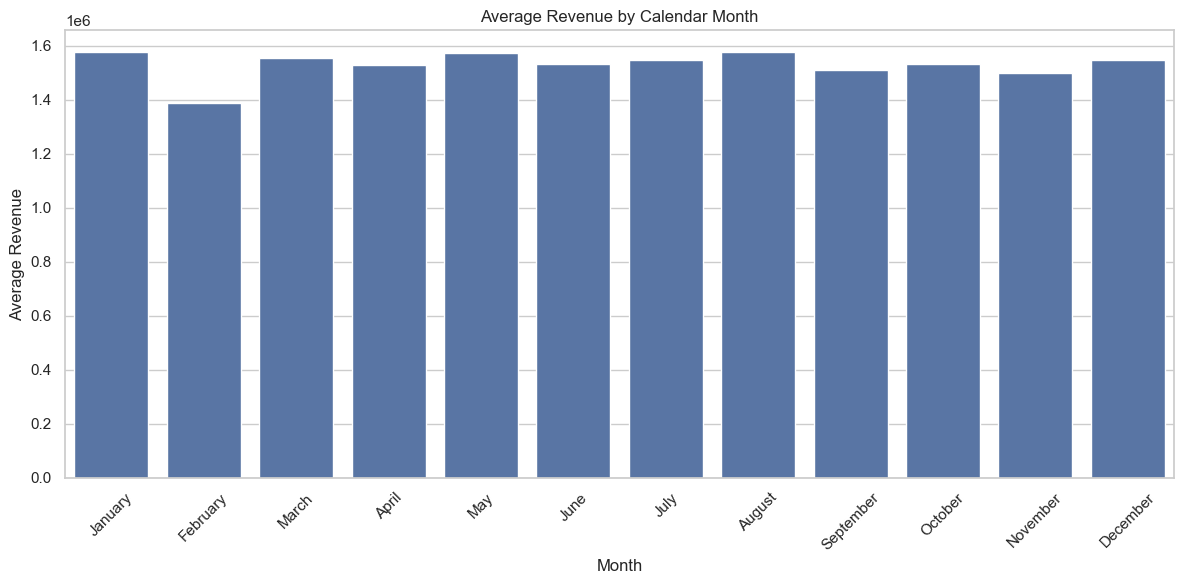

In [59]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_seasonality,
    x="MonthName",
    y="TotalAmount"
)

plt.title("Average Revenue by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [60]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Units Sold",
        "Total Customers",
        "Total Products",
        "Average Order Value",
        "Repeat Customer Rate",
        "Return Rate",
        "Cancellation Rate",
        "Average Discount"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_units,
        total_customers,
        total_products,
        average_order_value,
        repeat_customer_rate,
        return_rate,
        cancel_rate,
        df["Discount"].mean()
    ]
})

eda_summary

,Metric,Value
0,Total Revenue,9.182565e+07
1,Total Orders,1.000000e+05
2,Total Units Sold,3.001400e+05
3,Total Customers,4.323300e+04
4,Total Products,5.000000e+01
5,Average Order Value,9.182565e+02
6,Repeat Customer Rate,6.869984e+01
7,Return Rate,3.049000e+00
8,Cancellation Rate,3.028000e+00
9,Average Discount,7.422600e-02


In [61]:
output_dir = Path("../Data/EDA_Outputs")

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory ready.")

Output directory ready.


In [62]:
yearly_sales.to_csv(
    output_dir / "yearly_sales.csv",
    index=False
)

monthly_sales.to_csv(
    output_dir / "monthly_sales.csv",
    index=False
)

category_sales.to_csv(
    output_dir / "category_sales.csv"
)

brand_sales.to_csv(
    output_dir / "brand_sales.csv"
)

product_sales.to_csv(
    output_dir / "product_sales.csv"
)

payment_summary.to_csv(
    output_dir / "payment_summary.csv"
)

customer_summary.to_csv(
    output_dir / "customer_summary.csv"
)

country_sales.to_csv(
    output_dir / "country_sales.csv"
)

eda_summary.to_csv(
    output_dir / "eda_summary.csv",
    index=False
)

print("EDA summary tables exported successfully.")

EDA summary tables exported successfully.


In [63]:
highest_revenue_year = yearly_sales.loc[
    yearly_sales["Revenue"].idxmax()
]

print(
    f"Highest revenue year: "
    f"{int(highest_revenue_year['Year'])} "
    f"with ${highest_revenue_year['Revenue']:,.2f}"
)

Highest revenue year: 2020 with $18,529,864.02


In [64]:
highest_category = category_sales.iloc[0]

print(
    f"Top category: "
    f"{highest_category.name} "
    f"with ${highest_category['Revenue']:,.2f}"
)

Top category: Electronics with $15,584,217.18


In [65]:
highest_brand = brand_sales.iloc[0]

print(
    f"Top brand: "
    f"{highest_brand.name} "
    f"with ${highest_brand['Revenue']:,.2f}"
)

Top brand: CoreTech with $9,343,720.59


In [66]:
top_product = product_sales.iloc[0]

print(
    f"Top product: "
    f"{top_product.name[1]} "
    f"with ${top_product['Revenue']:,.2f}"
)

Top product: Memory Card 128GB with $1,935,138.40


In [67]:
top_country = country_sales.iloc[0]

print(
    f"Top country: "
    f"{top_country.name} "
    f"with ${top_country['Revenue']:,.2f}"
)

Top country: United States with $64,310,048.50


In [68]:
most_used_payment = (
    df["PaymentMethod"]
    .value_counts()
    .idxmax()
)

print(
    f"Most-used payment method: "
    f"{most_used_payment}"
)

Most-used payment method: Credit Card


# 15. Conclusion

The exploratory data analysis provided an initial understanding of the Amazon-style e-commerce dataset across sales, products, customers, order status, payment methods, discounts, and geography.

The analysis identified:

- Overall revenue and order performance
- Yearly and monthly sales patterns
- High-performing categories and brands
- Top-performing products
- Customer purchase frequency and repeat-customer behavior
- Order-status distribution
- Payment-method preferences
- Discount patterns
- Country-level revenue distribution
- Relationships between important numerical variables

The findings from this notebook will be used to define focused business questions for the subsequent analytical notebooks and PostgreSQL analysis.

Detailed customer segmentation, discount effectiveness, seller performance, and other deeper analyses will be investigated separately rather than overcrowding this exploratory notebook.